# **Exploratory Data Analysis - Diabetes**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath('../src'))

from preprocess import basic_cleaning, feature_engineering

data_path = os.path.join('..', 'data', 'raw', 'Diabetes_and_LifeStyle_Dataset .csv')
diabetes_df = pd.read_csv(data_path)

# Apply the cleaning function defined in preprocess.py to the dataset
diabetes_df = basic_cleaning(diabetes_df)

print(f"Dataset loaded successfully. Shape: {diabetes_df.shape}")

Dataset loaded successfully. Shape: (97297, 31)


## Dataset Description

The Diabetes and Health Indicators Dataset contains records reflecting the health profile of an individual, combining demographic attributes, lifestyle behaviors, family medical history, and physiological measurements.

The variables simulate realistic medical distributions derived from public health research, preserving data privacy while maintaining the analytical validity necessary for reliable studies and predictions.

The dataset variables are presented in the table below.

| Column Name | Description (English) | Descripción (Español) |
|--------------|-----------------------|------------------------|
| Age | Age of the individual in years. | Edad del individuo en años. |
| gender | Biological sex of the individual (Male/Female/Other). | Sexo biológico del individuo (Masculino/Femenino/Otro). |
| ethnicity | Ethnic background of the individual. (White, Hispanic, Black, Asian, Other)| Origen étnico del individuo. |
| education_level | Highest education attained (No formal, High school, Graduate, etc.). | Nivel educativo más alto alcanzado (Sin estudios, Secundaria, Universitario, etc.). |
| income_level | Economic status categorized into income groups (Low, Medium, High). | Nivel económico clasificado en grupos de ingreso (Bajo, Medio, Alto). |
| employment_status | Employment type or occupational status (Employed, Unemployed, Retired, Student). | Tipo o estado laboral (Empleado, Desempleado, Jubilado, Estudiante). |
| smoking_status | Smoking behavior (Never, Former, Current). | Hábito de fumar (Nunca, Exfumador, Actual). |
| alcohol_consumption_per_week | Average alcoholic drinks consumed per week. | Promedio de bebidas alcohólicas consumidas por semana. |
| physical_activity_minutes_per_week | Minutes spent in physical activity weekly. | Minutos dedicados a la actividad física semanalmente. |
| diet_score | Numerical score representing dietary quality (higher = healthier). | Puntaje numérico que representa la calidad de la dieta (mayor = más saludable). |
| sleep_hours_per_day | Average number of sleeping hours per day. | Promedio de horas de sueño por día. |
| screen_time_hours_per_day | Average hours of daily screen usage. | Promedio de horas de uso de pantallas por día. |
| family_history_diabetes | Indicates if a family history of diabetes exists (0 = No, 1 = Yes). | Indica si existe historial familiar de diabetes (0 = No, 1 = Sí). |
| hypertension_history | Records the presence of hypertension (0 = No, 1 = Yes). | Registra la presencia de hipertensión (0 = No, 1 = Sí). |
| cardiovascular_history | Indicates past cardiovascular conditions (0 = No, 1 = Yes). | Indica antecedentes de enfermedades cardiovasculares (0 = No, 1 = Sí). |
| bmi | Body Mass Index (BMI) measured in kg/m². | Índice de masa corporal (IMC) medido en kg/m². |
| waist_to_hip_ratio | Ratio of waist circumference to hip circumference. | Relación entre la circunferencia de cintura y cadera. |
| systolic_bp | Systolic blood pressure measurement (mmHg). | Medición de la presión arterial sistólica (mmHg). |
| diastolic_bp | Diastolic blood pressure measurement (mmHg). | Medición de la presión arterial diastólica (mmHg). |
| heart_rate | Resting heart rate (beats per minute). | Frecuencia cardíaca en reposo (latidos por minuto). |
| cholesterol_total | Total cholesterol level (mg/dL). | Nivel total de colesterol (mg/dL). |
| hdl_cholesterol | High-density lipoprotein (HDL) cholesterol (mg/dL). | Colesterol HDL (“bueno”) (mg/dL). |
| ldl_cholesterol | Low-density lipoprotein (LDL) cholesterol (mg/dL). | Colesterol LDL (“malo”) (mg/dL). |
| triglycerides | Triglyceride level in the blood (mg/dL). | Nivel de triglicéridos en la sangre (mg/dL). |
| glucose_fasting | Fasting blood glucose level (mg/dL). | Nivel de glucosa en ayunas (mg/dL). |
| glucose_postprandial | Post-meal glucose level (mg/dL). | Nivel de glucosa después de comer (mg/dL). |
| insulin_level | Blood insulin concentration (µU/mL). | Concentración de insulina en sangre (µU/mL). |
| hba1c | Glycated hemoglobin percentage (HbA1c %). | Porcentaje de hemoglobina glicosilada (HbA1c %). |
| diabetes_risk_score | Composite risk score estimating diabetes likelihood. | Puntaje compuesto que estima la probabilidad de diabetes. |
| diabetes_stage | Indicates disease stage (No Diabetes, Pre-Diabetes, Type 1, Type 2, Gestational). | Indica la etapa de la enfermedad (Sin diabetes, Prediabetes, Tipo 1, Tipo 2, Gestacional). |
| diagnosed_diabetes | Target variable showing diabetes diagnosis (0 = No, 1 = Yes). | Variable objetivo que indica el diagnóstico de diabetes (0 = No, 1 = Sí). |

* **HDL Cholesterol**: known as "good cholesterol", it helps remove excess cholesterol from the blood. High levels are generally associated with a lower risk of heart disease.

* **LDL Cholesterol**: referred to as "bad cholesterol", it can accumulate in artery walls and increase the risk of cardiovascular problems. Elevated values are a warning sign.

* **Triglycerides**: a type of fat found in the blood that the body uses as an energy source. High levels can indicate poor metabolic regulation or a diet high in sugars and fats.

* **Glucose Fasting**: measures blood sugar levels after at least 8 hours without eating. It is one of the main tests for detecting prediabetes or diabetes.

* **Glucose Postprandial**: represents blood sugar levels after eating. It helps evaluate how the body responds to food intake.

* **Insulin Level**: measures the amount of insulin the body produces to control glucose. Abnormal values may indicate insulin resistance.

* **HbA1c (Glycated Hemoglobin)**: reflects the average blood sugar level over the past three months. It is a key indicator for the diagnosis and management of diabetes.

For a better understanding, the healthy ranges for each of the variables mentioned above are presented below:

| Variable                 | Normal / Healthy Range                     | Notes                                                                           |
| ------------------------ | ------------------------------------------ | ------------------------------------------------------------------------------- |
| **HDL Cholesterol**      | Men: > 40 mg/dL<br>Women: > 50 mg/dL       | Higher values are better; low levels increase cardiovascular risk.              |
| **LDL Cholesterol**      | < 100 mg/dL                                | Considered "optimal"; 100–129 is acceptable; > 160 indicates high risk.         |
| **Triglycerides**        | < 150 mg/dL                                | 150–199 is "borderline high"; > 200 is considered elevated.                     |
| **Glucose Fasting**      | 70–99 mg/dL                                | 100–125 indicates *prediabetes*; ≥ 126 suggests *diabetes*.                     |
| **Glucose Postprandial** | < 140 mg/dL (2 h after eating)             | 140–199 indicates *prediabetes*; ≥ 200 is associated with *diabetes*.           |
| **Insulin Level**        | 2–25 µU/mL (fasting)                       | High values may indicate insulin resistance.                                    |
| **HbA1c**                | < 5.7 %                                    | 5.7–6.4 % = *prediabetes*; ≥ 6.5 % = *diabetes*.                                |

In [2]:
diabetes_df.head()

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [3]:
diabetes_df.shape

(97297, 31)

From the `.shape()` above, it is observed that the dataset contains 97,297 records and 31 variables, indicating a large and sufficient sample size to perform exploratory analysis and build a predictive model with good generalization capacity.

In [4]:
diabetes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  str    
 2   ethnicity                           97297 non-null  str    
 3   education_level                     97297 non-null  str    
 4   income_level                        97297 non-null  str    
 5   employment_status                   97297 non-null  str    
 6   smoking_status                      97297 non-null  str    
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297 non-null  

The `.info()` output shows no null values are present, meaning there is no need to fill, drop, or impute any values in the dataset.

In [5]:
print(diabetes_df.duplicated().sum())

0


Using `duplicated().sum()` confirms that the dataset has no duplicate records.

## Dataset Distributions

In [6]:
# Distribution of significant variables
print("\n-------------- DIAGNOSED_DIABETES DISTRIBUTION --------------")
print(diabetes_df['diagnosed_diabetes'].value_counts()) # counts
print(diabetes_df['diagnosed_diabetes'].value_counts(normalize=True)) # proportions

print("\n-------------- DIABETES_STAGE DISTRIBUTION --------------")
print(diabetes_df['diabetes_stage'].value_counts())
print(diabetes_df['diabetes_stage'].value_counts(normalize=True))

# Unique categories of categorical variables
print("\n-------------- CATEGORICAL VARIABLE CATEGORIES --------------")
for column in ['gender', 'ethnicity', 'education_level', 'smoking_status']:
    print(f"\n{column}:")
    print(diabetes_df[column].value_counts())


-------------- DIAGNOSED_DIABETES DISTRIBUTION --------------
diagnosed_diabetes
1    58382
0    38915
Name: count, dtype: int64
diagnosed_diabetes
1    0.600039
0    0.399961
Name: proportion, dtype: float64

-------------- DIABETES_STAGE DISTRIBUTION --------------
diabetes_stage
Type 2          58163
Pre-Diabetes    31013
No Diabetes      7737
Gestational       267
Type 1            117
Name: count, dtype: int64
diabetes_stage
Type 2          0.597788
Pre-Diabetes    0.318746
No Diabetes     0.079519
Gestational     0.002744
Type 1          0.001203
Name: proportion, dtype: float64

-------------- CATEGORICAL VARIABLE CATEGORIES --------------

gender:
gender
Female    48873
Male      46460
Other      1964
Name: count, dtype: int64

ethnicity:
ethnicity
White       43798
Hispanic    19552
Black       17504
Asian       11527
Other        4916
Name: count, dtype: int64

education_level:
education_level
Highschool      43651
Graduate        34097
Postgraduate    14552
No formal       

From the distributions above, the following observations can be made:

- **Diagnosed_diabetes**: 60% of individuals have a diabetes diagnosis, while 40% do not. This indicates a slight imbalance in the target variable.

- **Diabetes_stage**: the majority of cases correspond to Type 2 diabetes (59.8%), followed by pre-diabetes (31.9%) and a smaller proportion with no diabetes (7.9%). Gestational (0.27%) and Type 1 (0.12%) stages are very infrequent.

- **Gender**: there is a balanced distribution between men (≈ 46%) and women (≈ 50%), with a small fraction (≈ 2%) identifying as "Other".

- **Ethnicity**: White individuals predominate (≈ 45%), followed by Hispanic (20%), Black (18%), Asian (12%), and Other (5%), suggesting some ethnic diversity in the sample.

- **Education_level**: the majority have secondary (45%) or university-level education (35%), and 15% have postgraduate studies; only 5% have no formal education.

- **Smoking_status**: more than half have never smoked (≈ 60%), while the rest is split almost equally between current smokers (20%) and former smokers (20%).

In [ ]:
# View basic statistics for numerical variables
print(diabetes_df.describe())

# Key variables
key_features = ['Age', 'bmi', 'glucose_fasting', 'hba1c',
                'systolic_bp', 'diastolic_bp']

for variable in key_features:
    mean_positive = diabetes_df[diabetes_df['diagnosed_diabetes']==1][variable].mean()
    mean_negative = diabetes_df[diabetes_df['diagnosed_diabetes']==0][variable].mean()

    print(f"\n{variable}:")
    print(f"  With diabetes: {mean_positive:.1f}")
    print(f"  Without diabetes: {mean_negative:.1f}")

                Age  alcohol_consumption_per_week  \
count  97297.000000                  97297.000000   
mean      50.192699                      2.004543   
std       15.492557                      1.418060   
min       19.000000                      0.000000   
25%       38.000000                      1.000000   
50%       51.000000                      2.000000   
75%       61.000000                      3.000000   
max       90.000000                     10.000000   

       physical_activity_minutes_per_week    diet_score  sleep_hours_per_day  \
count                        97297.000000  97297.000000         97297.000000   
mean                           118.942886      5.995214             6.997708   
std                             84.441920      1.780096             1.093726   
min                              0.000000      0.000000             3.000000   
25%                             57.000000      4.800000             6.300000   
50%                            100.000000 

The cell above performs a descriptive analysis of the dataset's numerical variables. First, the `describe()` method provides a general summary to observe the mean, dispersion, and ranges of each variable. Then, the averages of key variables (such as age, body mass index (BMI), glucose levels, glycated hemoglobin (HbA1c), and blood pressure) are calculated, differentiating between individuals with and without a diabetes diagnosis.

In [ ]:
# Check the relationship between diagnosed_diabetes and diabetes_stage
print(pd.crosstab(diabetes_df['diagnosed_diabetes'],
                diabetes_df['diabetes_stage'],
                margins=True))

# Check for inconsistent cases
print("\nRows/cases with diagnosed_diabetes=0 but not No Diabetes")
inconsistent = diabetes_df[
    (diabetes_df['diagnosed_diabetes'] == 0) &
    (diabetes_df['diabetes_stage'] != 'No Diabetes') &
    (diabetes_df['diabetes_stage'] != 'Pre-Diabetes')
]
print(f"Total inconsistent cases: {len(inconsistent)}")
print(inconsistent['diabetes_stage'].value_counts())

diabetes_stage      Gestational  No Diabetes  Pre-Diabetes  Type 1  Type 2  \
diagnosed_diabetes                                                           
0                           111         7737         31013      54       0   
1                           156            0             0      63   58163   
All                         267         7737         31013     117   58163   

diabetes_stage        All  
diagnosed_diabetes         
0                   38915  
1                   58382  
All                 97297  

Rows/cases with diagnosed_diabetes=0 but not No Diabetes
Total casos inconsistentes: 165
diabetes_stage
Gestational    111
Type 1          54
Name: count, dtype: int64


The cross-tabulation between **diagnosed_diabetes** and **diabetes_stage** shows a logical correspondence between the two variables: diagnosed individuals are concentrated in diabetic stages (mainly Type 2), while those without a diagnosis appear mostly in No Diabetes or Pre-Diabetes. However, some *inconsistent cases* are identified where diagnosed_diabetes = 0 but the stage corresponds to a type of diabetes. These records will be removed to ensure data coherence.

In [9]:
diabetes_df.groupby(by = ['diabetes_stage', 'diagnosed_diabetes'],as_index= False)['Age'].count().sort_values(by = 'Age', ascending=False)
# The Age column is used only to count cases per group, not to analyze age.

,diabetes_stage,diagnosed_diabetes,Age
6,Type 2,1,58163
3,Pre-Diabetes,0,31013
2,No Diabetes,0,7737
1,Gestational,1,156
0,Gestational,0,111
5,Type 1,1,63
4,Type 1,0,54


In [ ]:
'''
Delete inconsistent records, this is because 165 cases were found where 
diagnosed_diabetes is zero and the diabetes stage indicated as if they had it.
'''
diabetes_df = diabetes_df[~(
    (diabetes_df['diabetes_stage'].isin(['Type 1', 'Gestational'])) &
    (diabetes_df['diagnosed_diabetes'] == 0)
)]

In [11]:
# Confirm rows have been deleted
diabetes_df.groupby(['diabetes_stage', 'diagnosed_diabetes'])['Age'].count()

diabetes_stage  diagnosed_diabetes
Gestational     1                       156
No Diabetes     0                      7737
Pre-Diabetes    0                     31013
Type 1          1                        63
Type 2          1                     58163
Name: Age, dtype: int64

In [12]:
diabetes_df.shape

(97132, 31)

In [13]:
diabetes_df.groupby(by = ['family_history_diabetes', 'diagnosed_diabetes'],
                    as_index= False)['Age'].count().sort_values(by = 'Age', ascending=False)

,family_history_diabetes,diagnosed_diabetes,Age
1,0,1,41632
0,0,0,34143
3,1,1,16750
2,1,0,4607


The data suggest a positive correlation between family history and the presence of a diabetes diagnosis. However, a sizeable group with family history but no diagnosis is also observed, which could represent a key population for prevention and early detection.

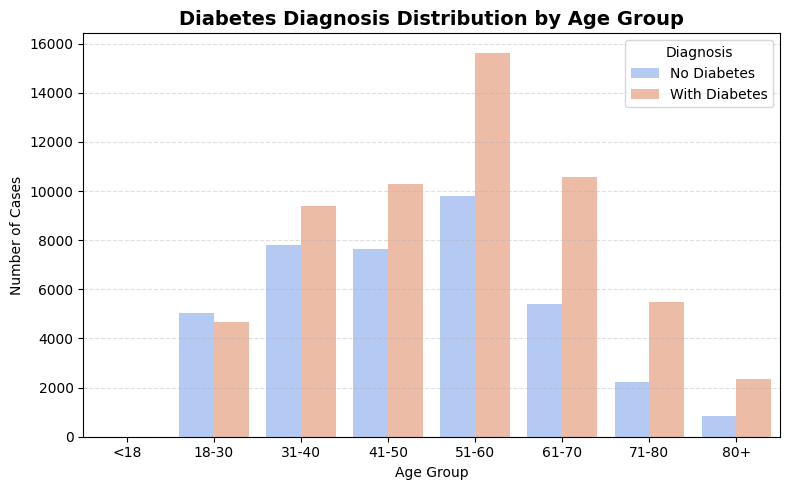

In [14]:
diabetes_df = diabetes_df.copy()

# Create age groups
bins = [0, 18, 30, 40, 50, 60, 70, 80, 100]
labels = ['<18', '18-30', '31-40', '41-50', '51-60', '61-70', '71-80', '80+']
diabetes_df.loc[:, 'age_group'] = pd.cut(diabetes_df['Age'], bins=bins, labels=labels, right=False)


# Convert target to text labels
diabetes_df.loc[:, 'diagnosis_label'] = diabetes_df['diagnosed_diabetes'].map({0: 'No Diabetes', 1: 'With Diabetes'})

# Group
age_diagnosis = diabetes_df.groupby(['age_group', 'diagnosis_label'], as_index=False, observed=False)['Age'].count()
age_diagnosis.rename(columns={'Age': 'count'}, inplace=True)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot( data=age_diagnosis, x='age_group', y='count', hue='diagnosis_label', palette='coolwarm')
plt.title("Diabetes Diagnosis Distribution by Age Group", fontsize=14, weight='bold')
plt.xlabel("Age Group")
plt.ylabel("Number of Cases")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.show()


In [ ]:
# Create count table
count_table = diabetes_df.groupby(['age_group', 'diagnosed_diabetes'], observed=True)['Age'].count().unstack().fillna(0)
labels = ['<18', '18-30', '31-40', '41-50', '51-60', '61-70', '71-80', '80+']

# Rename columns
count_table.columns = ['No Diabetes', 'With Diabetes']

# Display table sorted by age
count_table = count_table.reindex(labels)
count_table

,No Diabetes,With Diabetes
age_group,,
<18,NaN,NaN
18-30,5034.0,4664.0
31-40,7815.0,9401.0
41-50,7636.0,10304.0
51-60,9793.0,15636.0
61-70,5399.0,10554.0
71-80,2217.0,5483.0
80+,856.0,2340.0


The table and chart show something quite evident: as age increases, so does the number of diabetes diagnoses. The 51–70 age groups concentrate the most cases, while younger individuals have a much lower incidence.

Overall, there is a clear relationship between age and the risk of developing the disease, which aligns with what is commonly observed in medical practice.

In [ ]:
# Diagnosis distribution by gender and diabetes stage
diabetes_df.groupby(by=['gender', 'diabetes_stage'], as_index=False)['diagnosed_diabetes'].count().sort_values(by='diagnosed_diabetes', ascending=False)


,gender,diabetes_stage,diagnosed_diabetes
4,Female,Type 2,29063
8,Male,Type 2,27875
2,Female,Pre-Diabetes,15598
6,Male,Pre-Diabetes,14855
1,Female,No Diabetes,3891
5,Male,No Diabetes,3672
12,Other,Type 2,1225
10,Other,Pre-Diabetes,560
9,Other,No Diabetes,174
0,Female,Gestational,156


A clear distribution of diabetes diagnosis by sex and disease stage is observed, revealing several important patterns:

* Type 2 diabetes predominates in both sexes, being slightly more prevalent in women (29,063 cases) than in men (27,875 cases). This reinforces the general trend seen in epidemiological studies, where Type 2 diabetes affects both genders but may have a slightly **higher incidence in adult women**.

* For pre-diabetes, the distribution is more balanced between genders, though women again show slightly higher counts. This may reflect greater medical follow-up or higher biological susceptibility in certain age groups.

* Gestational diabetes appears exclusively in women, as expected given its biological nature.

* Type 1 diabetes, while rare in both sexes, appears slightly more often in men.

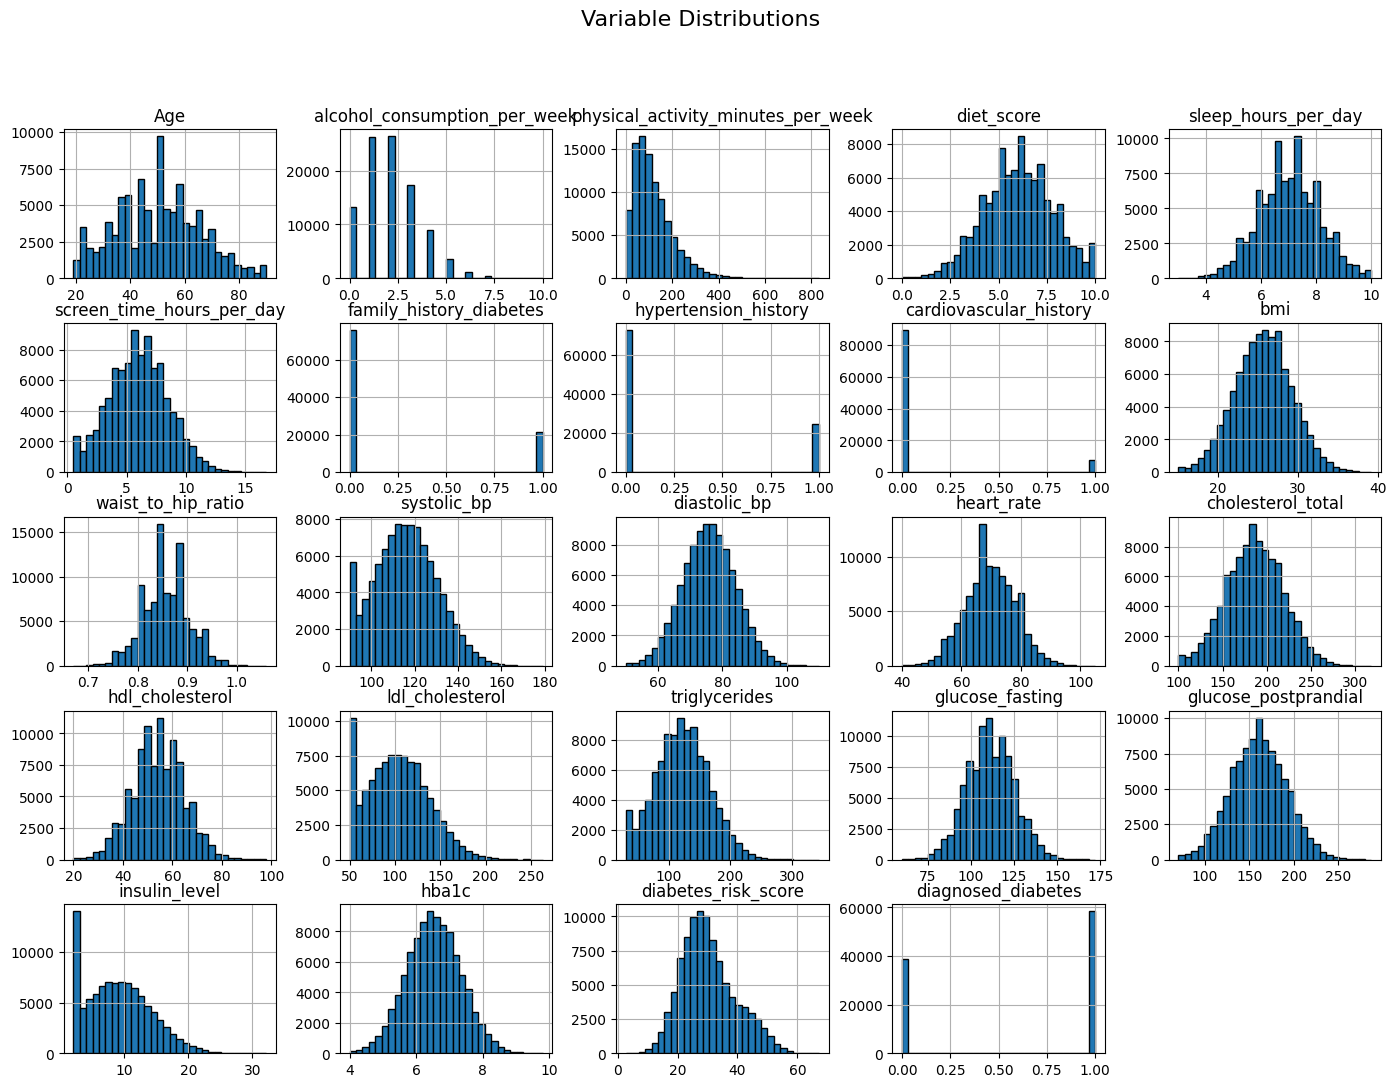

In [17]:
# Histogram of numerical variables
diabetes_df.hist(
    figsize=(17, 12),
    bins=30,
    color="#1f77b4",
    edgecolor="black"
)
plt.suptitle("Variable Distributions", fontsize=16)
plt.show()

In general, the variables in the dataset show **mostly normal or symmetric distributions**, especially those related to clinical indicators such as glucose, cholesterol, blood pressure, and triglycerides, indicating a population with values concentrated around healthy ranges and few extreme cases. However, some variables display atypical behavior: weekly physical activity, alcohol consumption, and screen time are *strongly right-skewed*, showing that most individuals engage in little activity and maintain unhealthy habits. BMI is concentrated around overweight values, while the binary variables for medical history show a *predominance of negative responses*.

Overall, the distributions suggest a predominantly healthy population, but there are certain patterns of sedentary behavior and overweight that may be related to the risk of developing diabetes.


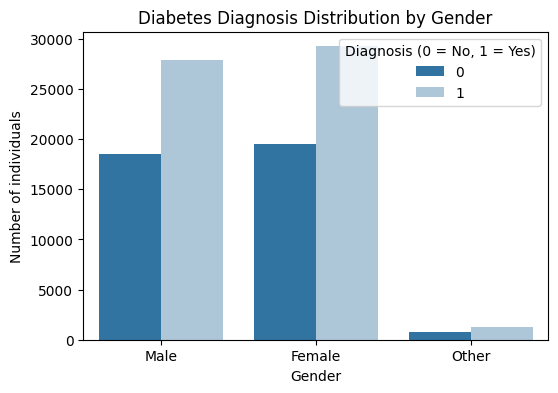

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=diabetes_df, x="gender", hue="diagnosed_diabetes", palette=["#1f77b4", "#a6c8e0"])
plt.title("Diabetes Diagnosis Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of individuals")
plt.legend(title="Diagnosis (0 = No, 1 = Yes)")
plt.show()

The chart shows that both men and women have a high proportion of individuals diagnosed with diabetes, although women have a slightly higher number of cases. In the "Other" group, the sample is very small, which does not allow for a meaningful comparison.

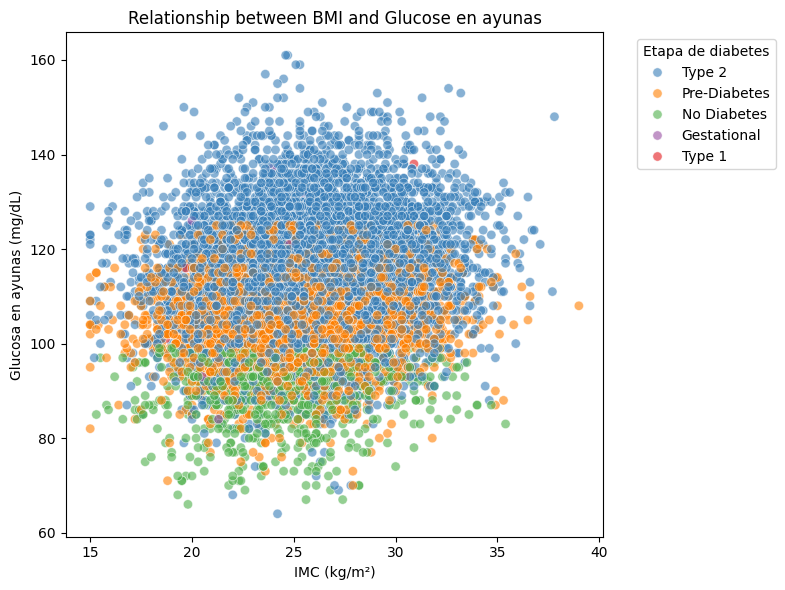

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=diabetes_df.sample(10000, random_state=1),
    x="bmi",
    y="glucose_fasting",
    hue="diabetes_stage",
    palette={
        "Type 1": "#E41A1C",       # rojo fuerte
        "Type 2": "#377EB8",       # azul intenso
        "Pre-Diabetes": "#FF7F00", # naranja brillante
        "No Diabetes": "#4DAF4A",  # verde vivo
        "Gestational": "#984EA3"   # violeta oscuro
    },
    alpha=0.6,
    s=45
)
plt.title("Relationship between BMI and Fasting Glucose")
plt.xlabel("BMI (kg/m²)")
plt.ylabel("Fasting glucose (mg/dL)")
plt.legend(title="Diabetes stage", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The chart shows a positive relationship between BMI and fasting glucose: higher BMI values tend to be associated with higher glucose levels. Cases without diabetes cluster at low values, pre-diabetes cases fall in an intermediate range, and Type 2 diabetes cases appear at the highest levels, suggesting that both variables could be key predictors of a diabetes diagnosis.

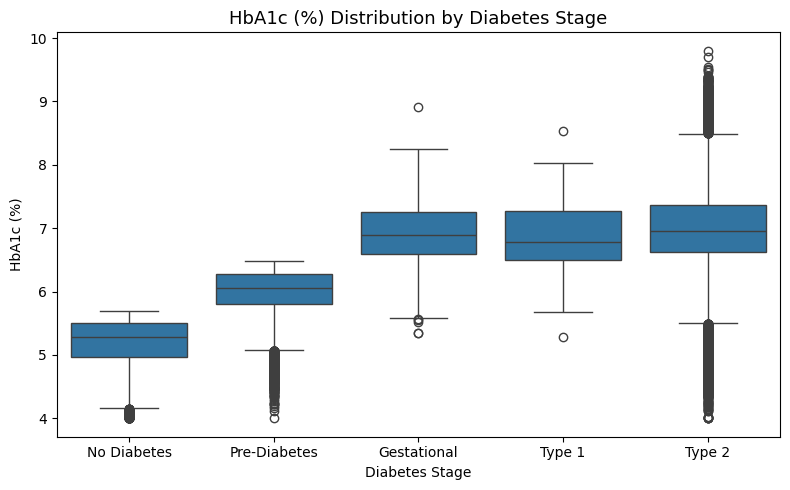

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=diabetes_df,
    x="diabetes_stage",
    y="hba1c",
    order=["No Diabetes", "Pre-Diabetes", "Gestational", "Type 1", "Type 2"]
)
plt.title("HbA1c (%) Distribution by Diabetes Stage", fontsize=13)
plt.xlabel("Diabetes Stage")
plt.ylabel("HbA1c (%)")
plt.tight_layout()
plt.show()

The chart shows that HbA1c values **increase** progressively with the diabetes stage: individuals without diabetes have the lowest levels, followed by those with pre-diabetes, while Type 1 and Type 2 diabetes cases exhibit the highest values. This trend confirms that **HbA1c is a strong indicator of glycemic control and a highly relevant variable for predicting diabetes**.

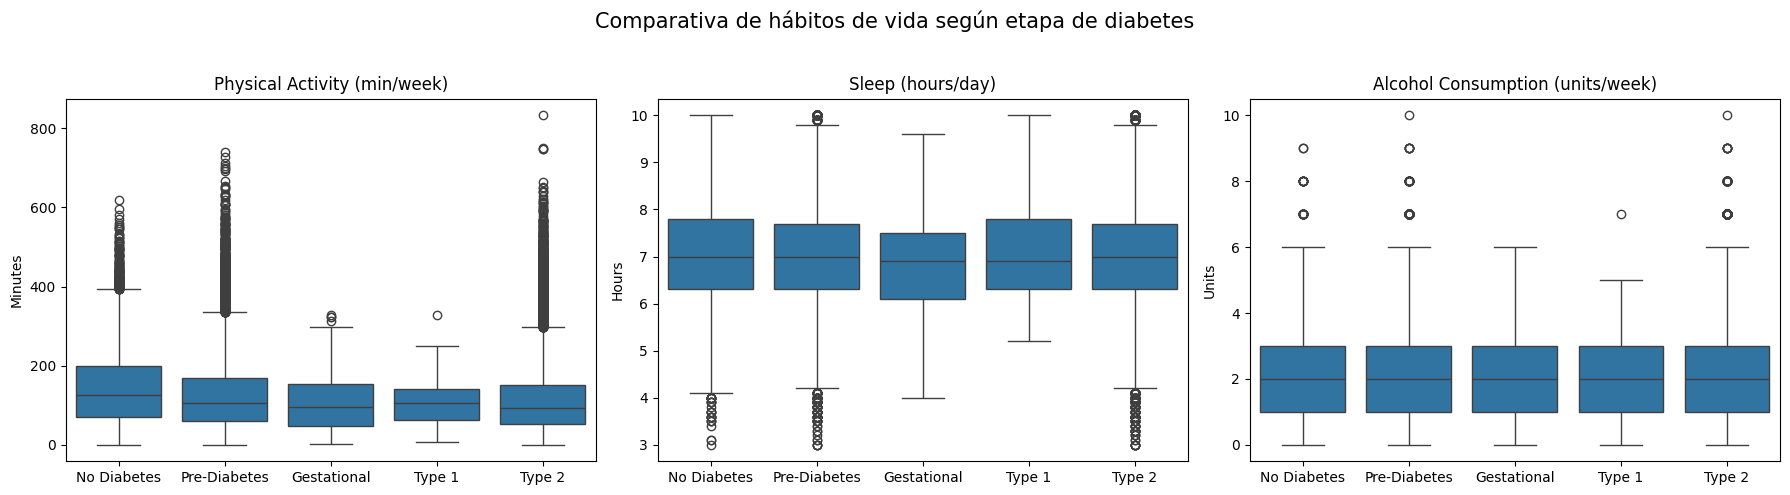

In [ ]:
variables = [
    ("physical_activity_minutes_per_week", "Physical Activity (min/week)", "Minutes"),
    ("sleep_hours_per_day", "Sleep (hours/day)", "Hours"),
    ("alcohol_consumption_per_week", "Alcohol Consumption (units/week)", "Units")
]
orden = ["No Diabetes", "Pre-Diabetes", "Gestational", "Type 1", "Type 2"]

fig, axes = plt.subplots(1, len(variables), figsize=(18, 5), sharex=True)

for ax, (col, title, ylabel) in zip(axes, variables):
    sns.boxplot(data=diabetes_df, x="diabetes_stage", y=col, order=orden, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

plt.suptitle("Lifestyle Habits by Diabetes Stage", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

The comparison shows that **weekly physical activity** presents a clear differentiation between groups, with higher levels in individuals without diabetes and a marked reduction in Type 2 diabetes patients, which could make it a relevant predictor of health status.

**Daily sleep hours** remain fairly similar across all diabetes groups, meaning this variable does not contribute much to differentiating between the disease stages.

Finally, **alcohol consumption** shows a slight decrease in more advanced diabetes stages, though the differences are not very pronounced, limiting its predictive value.

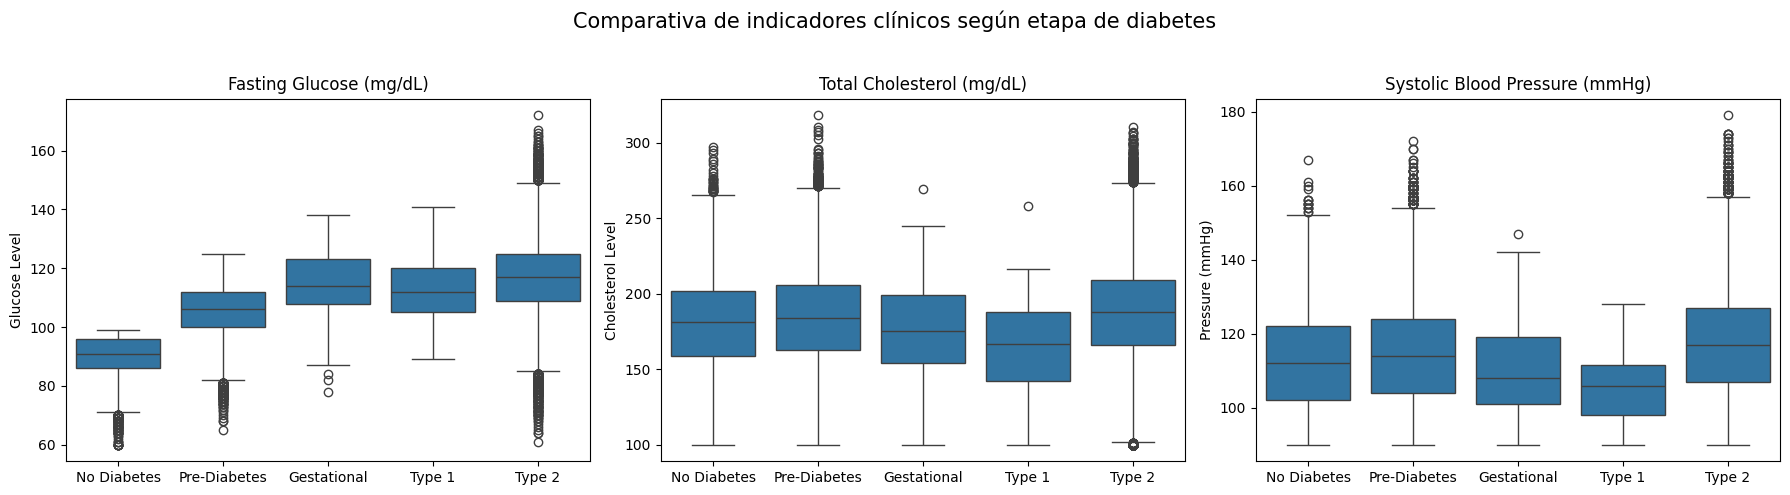

In [ ]:
variables = [
    ("glucose_fasting", "Fasting Glucose (mg/dL)", "Glucose Level"),
    ("cholesterol_total", "Total Cholesterol (mg/dL)", "Cholesterol Level"),
    ("systolic_bp", "Systolic Blood Pressure (mmHg)", "Pressure (mmHg)")
]
orden = ["No Diabetes", "Pre-Diabetes", "Gestational", "Type 1", "Type 2"]

fig, axes = plt.subplots(1, len(variables), figsize=(18, 5), sharex=True)

for ax, (col, title, ylabel) in zip(axes, variables):
    sns.boxplot(
        data=diabetes_df,
        x="diabetes_stage",
        y=col,
        order=orden,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)

plt.suptitle("Clinical Indicators by Diabetes Stage", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

This analysis shows that **fasting glucose** increases clearly from individuals without diabetes to those with Type 2 diabetes, making it a very useful indicator for differentiating groups.

**Total cholesterol** changes more mildly, with slightly higher values in pre-diabetes and Type 2, so it provides information but is not as decisive.

**Systolic blood pressure** tends to be higher in groups with diabetes, although with considerable variation, which makes it a complementary but not definitive predictor.

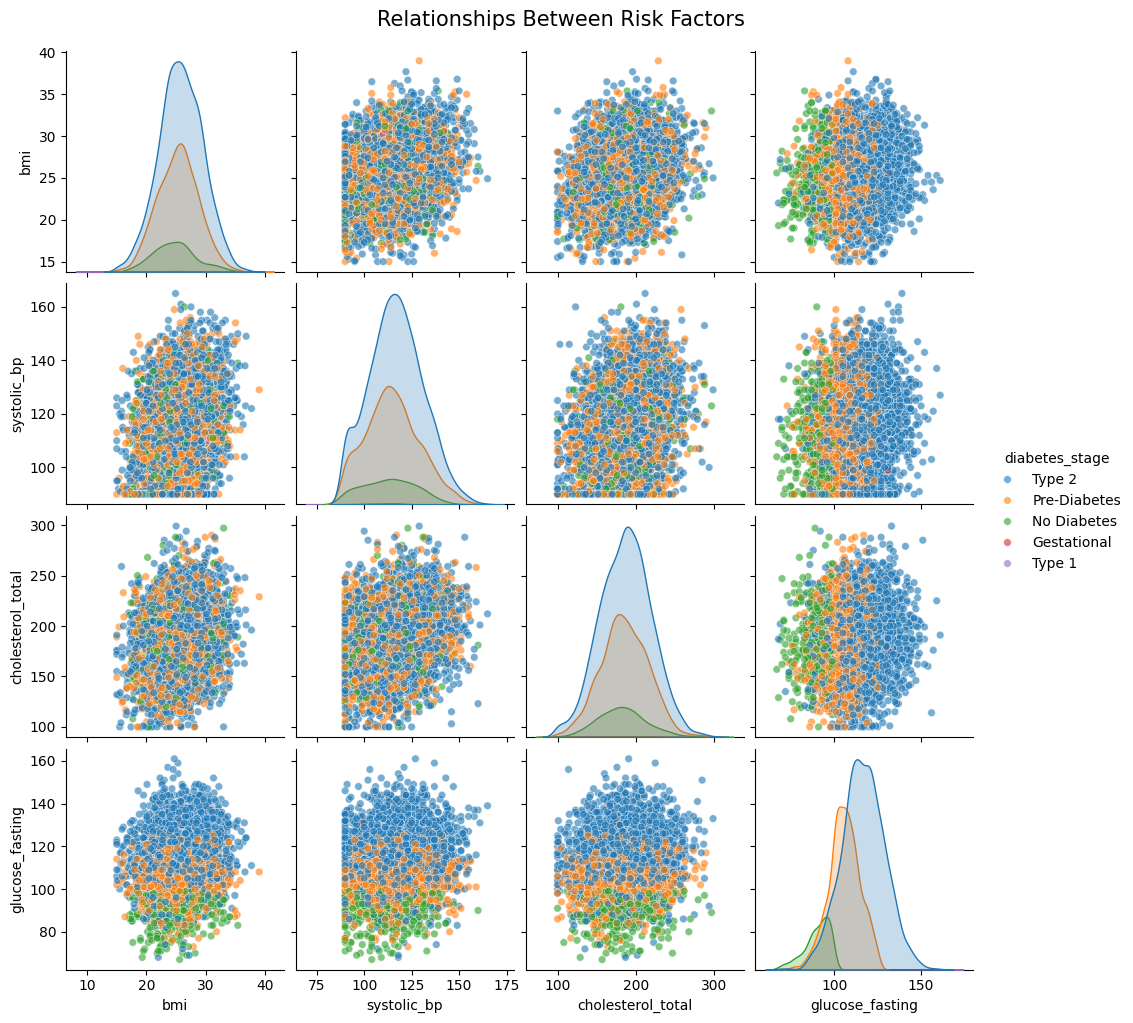

In [23]:

risk_factors = ["bmi", "systolic_bp", "cholesterol_total", "glucose_fasting", "diabetes_stage"]

sns.pairplot(
    diabetes_df[risk_factors].sample(5000, random_state=1),  # sample for better performance
    hue="diabetes_stage",
    diag_kind="kde",
    plot_kws={"alpha": 0.6, "s": 30}
)
plt.suptitle("Relationships Between Risk Factors", y=1.02, fontsize=15)
plt.show()

The risk factor relationship analysis shows that:
* Fasting glucose presents a clear separation between diabetes stages, confirming its high discriminant capacity.
* BMI and systolic pressure tend to increase in Type 2 diabetes, though with greater dispersion.
* Total cholesterol shows less variability between groups.

Although there are no strong linear correlations between variables, outliers are observed, such as elevated glucose values in individuals without a diagnosis, which could indicate possible erroneous records or undetected cases.


diagnosed_diabetes                    1.000000
hba1c                                 0.678393
glucose_postprandial                  0.628693
glucose_fasting                       0.510102
diabetes_risk_score                   0.277069
family_history_diabetes               0.198649
Age                                   0.136009
bmi                                   0.096732
systolic_bp                           0.095326
waist_to_hip_ratio                    0.078265
ldl_cholesterol                       0.067852
cholesterol_total                     0.058503
insulin_level                         0.057845
triglycerides                         0.056998
diastolic_bp                          0.035308
cardiovascular_history                0.029471
hypertension_history                  0.027122
heart_rate                            0.022713
screen_time_hours_per_day             0.017186
alcohol_consumption_per_week          0.001120
sleep_hours_per_day                  -0.000655
diet_score   

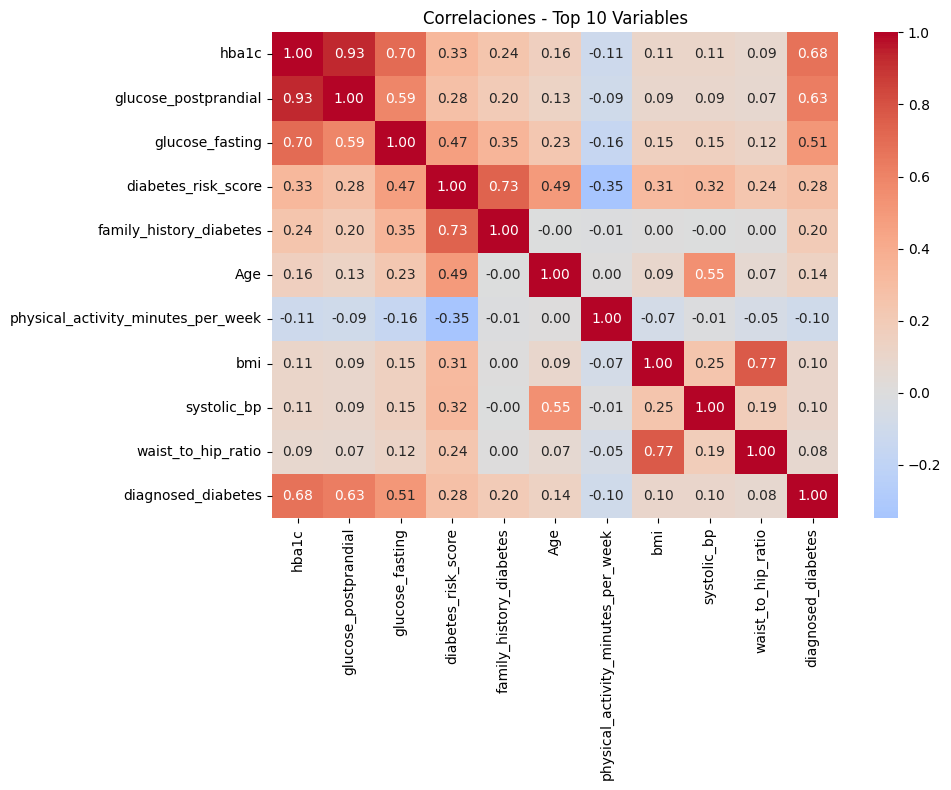

In [ ]:
# Correlation matrix with target
numeric_cols = diabetes_df.select_dtypes(include=[np.number]).columns
corr_with_target = diabetes_df[numeric_cols].corr()['diagnosed_diabetes'].sort_values(ascending=False)

print(corr_with_target)

# Heatmap of top correlations
top_vars = corr_with_target.abs().sort_values(ascending=False)[1:11].index
plt.figure(figsize=(10, 8))
sns.heatmap(diabetes_df[list(top_vars) + ['diagnosed_diabetes']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlations - Top 10 Variables')
plt.tight_layout()
plt.show()

The heatmap reveals that the variables with the highest positive correlation with a diabetes diagnosis are **fasting glucose** (0.51), **postprandial glucose** (0.63), and **HbA1c** (0.68), all with coefficients above 0.5, confirming their clinical relevance. Moderate correlations are also highlighted for **age** (0.14), **family history** (0.20), **BMI** (0.1), and **systolic pressure** (0.1). On the other hand, **physical activity** shows a negative correlation (-0.1), indicating that more active individuals are less likely to have a diabetes diagnosis.

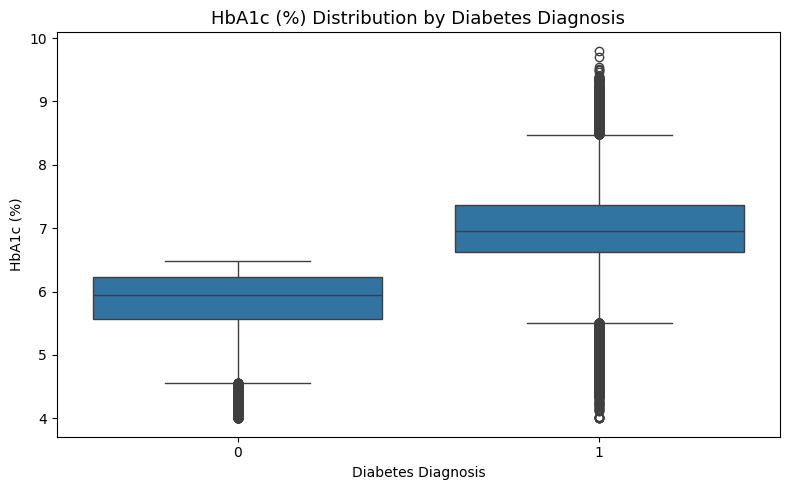

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=diabetes_df,
    x="diagnosed_diabetes",
    y="hba1c"
)
plt.title("HbA1c (%) Distribution by Diabetes Diagnosis", fontsize=13)
plt.xlabel("Diabetes Diagnosis")
plt.ylabel("HbA1c (%)")
plt.tight_layout()
plt.show()


The distribution of HbA1c (%) by diabetes diagnosis shows a clear separation between groups: individuals without a diagnosis have a median close to 6%, while those diagnosed reach values around 7%, with greater dispersion and the presence of outliers above 9%. This substantial difference confirms that HbA1c **is not only the most correlated marker with the diagnosis, but also one of the most effective for differentiating between clinical states**, reinforcing its selection as a key variable in the predictive model.

In [26]:
df = feature_engineering(diabetes_df)
df.head()

,Age,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,...,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,age_group,diagnosis_label,gender_Male,gender_Other
0,58,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,...,236,6.36,8.18,29.6,Type 2,1,51-60,With Diabetes,True,False
1,52,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,...,150,2.00,5.63,23.0,No Diabetes,0,51-60,No Diabetes,False,False
2,60,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,...,195,5.07,7.51,44.7,Type 2,1,61-70,With Diabetes,True,False
3,74,Black,Highschool,Low,Retired,Never,0,49,3.4,6.6,...,253,5.28,9.03,38.2,Type 2,1,71-80,With Diabetes,False,False
4,46,White,Graduate,Middle,Retired,Never,1,109,7.2,7.4,...,184,12.74,7.20,23.5,Type 2,1,41-50,With Diabetes,True,False


One-Hot Encoding was applied to the 'gender' variable to transform the categorical information into a numerical format compatible with the Random Forest model, avoiding ordinal bias and eliminating redundancy through the 'drop first' technique.


In [27]:
# Select variables for the model

model_variables = ['Age', 'bmi', 'glucose_fasting', 'hba1c', 'systolic_bp', 'family_history_diabetes', 'physical_activity_minutes_per_week',
    'gender_Male', 'gender_Other']

The selected variables represent the main factors associated with the development and diagnosis of diabetes from a medical and behavioral perspective. **HbA1c** and **fasting glucose** are the most direct clinical markers of glycemic control; **BMI** and **systolic blood pressure** represent metabolic and cardiovascular conditions frequently linked to the disease; **age** is a well-known risk factor that increases the probability of diagnosis; while **physical activity** and **family history** provide key information about habits and genetics. All of these variables offer a comprehensive view of diabetes risk and improve the model's predictive capacity.